In [6]:
from rdkit import Chem
from rdkit.Chem import rdDetermineBonds
import numpy as np
import pandas as pd 
from scipy.spatial.transform import Rotation as R
from scipy.spatial.distance import pdist, squareform
from pathlib import Path 
import tqdm
import umap
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import matplotlib.patches as mpatches


def xyz_to_rdkit_mol(xyz_file, total_charge):
    """
    Convert an XYZ file with explicit hydrogens to an RDKit Mol,
    preserving 3D coordinates and determining connectivity automatically.
    

    Parameters:
        xyz_file: path to XYZ file
        total_charge: total molecular charge (default 0)
    
    Returns:
        RDKit Mol object
    """
    # --- Read XYZ ---
    with open(xyz_file) as f:
        lines = f.readlines()[2:]  # skip atom count + comment
    atoms, coords = [], []

    for line in lines:
        parts = line.split()
        atoms.append(parts[0])
        coords.append([float(x) for x in parts[1:4]])
    coords = np.array(coords)
    
    # --- Create empty molecule with atoms ---
    mol = Chem.RWMol()
    z = [Chem.GetPeriodicTable().GetAtomicNumber(a) for a in atoms]
    for Zi in z:
        mol.AddAtom(Chem.Atom(Zi))
    
    # --- Add coordinates ---
    conf = Chem.Conformer(len(coords))
    for i, pos in enumerate(coords):
        conf.SetAtomPosition(i, pos)
    mol.AddConformer(conf)
    
    # --- Determine connectivity using RDKit's bond perception ---
    Chem.rdDetermineBonds.DetermineConnectivity(mol, charge=total_charge)
    
    # --- Sanitize molecule ---
    Chem.SanitizeMol(mol)
    
    return mol






def numpy_geom(mol):
    conf = mol.GetConformer()
    return np.array([list(conf.GetAtomPosition(i)) for i in range(mol.GetNumAtoms())])


In [45]:
smiles_folder = Path('/Users/connerbaucom/Desktop/Pieri/CTG/dim_red_comp/PhotoStats/data/aligned_geometries/substruct_match/benzene_smiles/0')


##MECIS must be aligned to reference used in smiles alignment.... 
mecis = [
    Path('../../../data/aligned_geometries/mcs/benzene/0081_15.xyz'),
    Path('../../../data/aligned_geometries/mcs/benzene/0178_7.xyz'),
    Path('../../../data/aligned_geometries/mcs/benzene/0070_13.xyz'),

]

In [ ]:


geometries = []
idx = []




for x in tqdm.tqdm(list(smiles_folder.glob('*'))):
   
    mol = xyz_to_rdkit_mol(x, total_charge=0)
    geom = numpy_geom(mol)
    flatten_geom = geom.flatten()
    idx.append(x.stem)
    geometries.append(flatten_geom)

for meci in mecis:

    mol = xyz_to_rdkit_mol(meci, total_charge=0)
    geom = numpy_geom(mol)
    flatten_geom = geom.flatten()
    idx.append(meci.stem)
    #geometries.append(flatten_geom)

    
feature_vector = np.array(geometries)


   

100%|██████████| 1110/1110 [00:05<00:00, 207.95it/s]


/opt/homebrew/anaconda3/envs/conf-align/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/homebrew/anaconda3/envs/conf-align/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/anaconda3/envs/conf-align/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/homebrew/anaconda3/envs/conf-align/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/homebrew/anaconda3/envs/conf-align/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/homebrew/anaconda3/envs/conf-align/lib/python3.12/site-packages/sklearn/utils/extmath

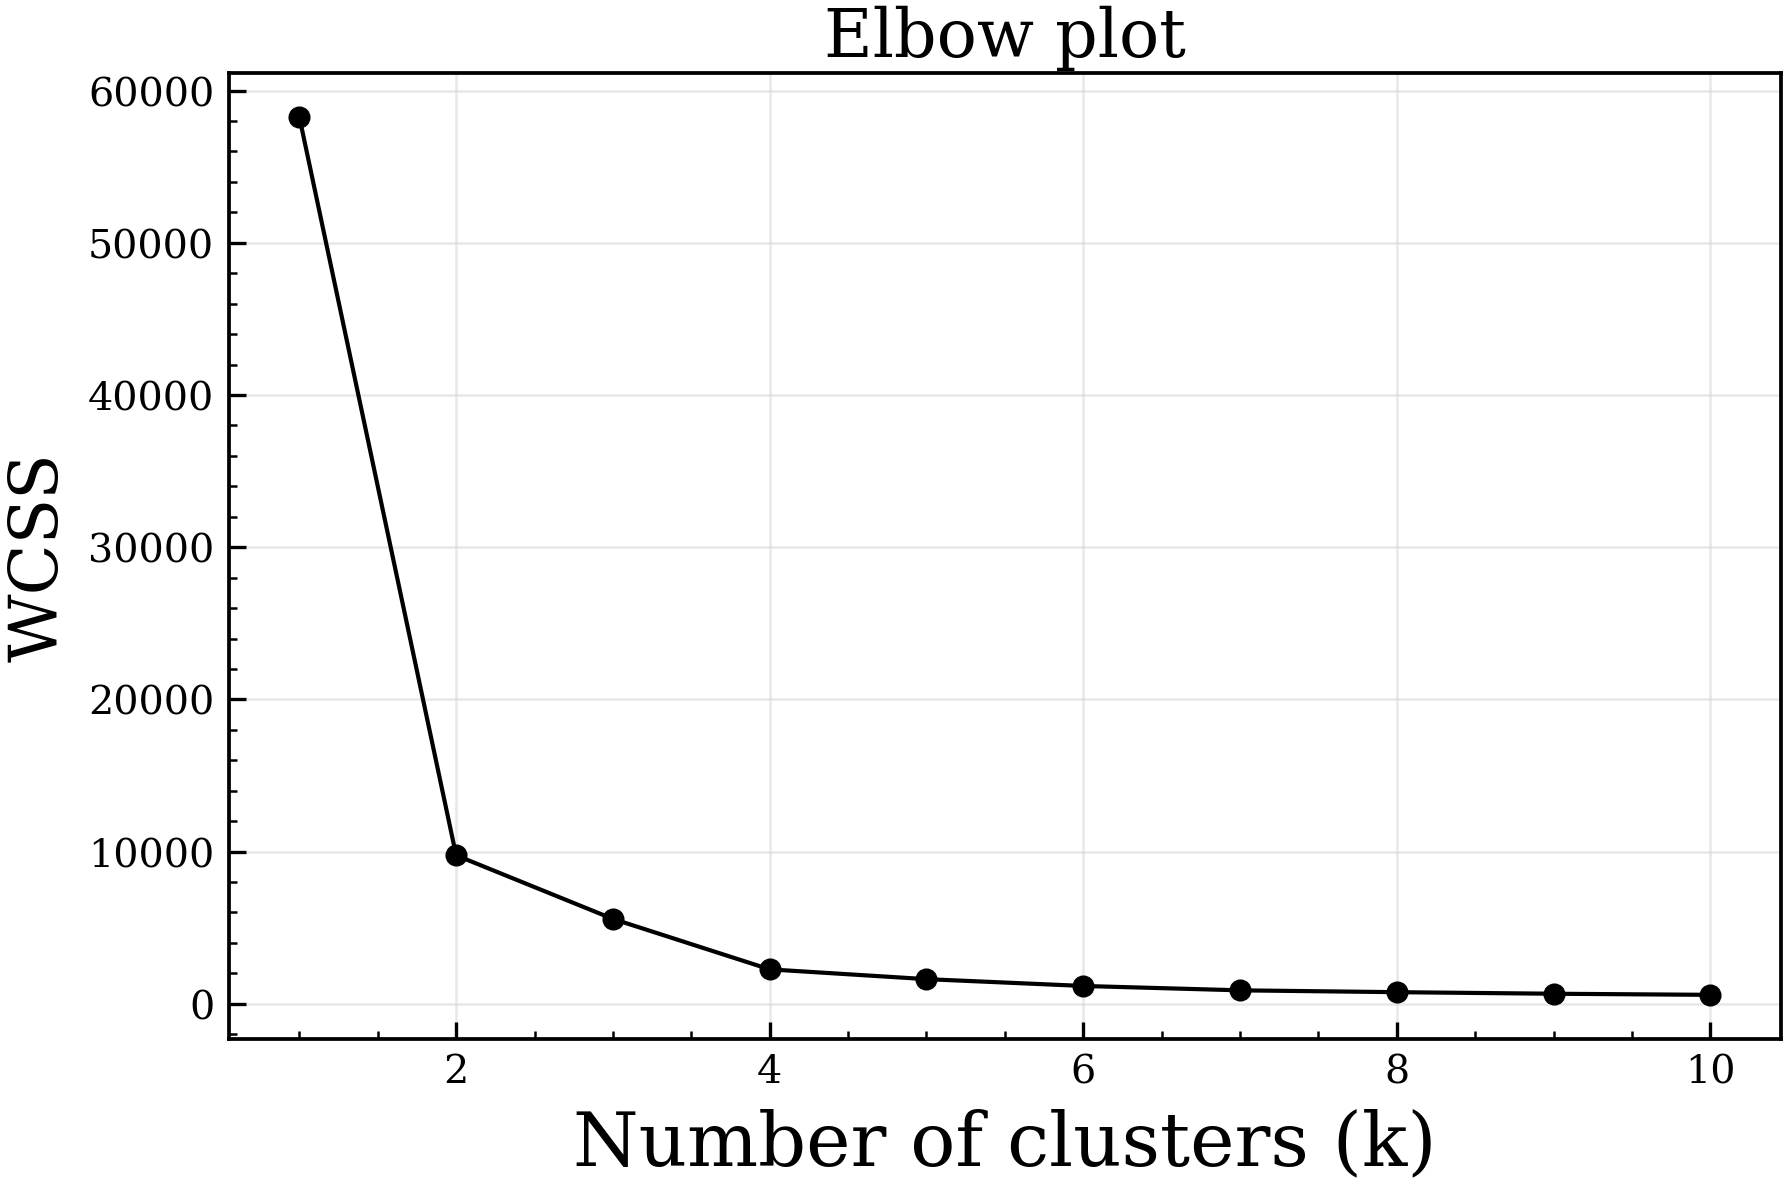

In [47]:
reducer = umap.UMAP(
        n_components=2,
        n_neighbors=10,
        min_dist=0.1,
        random_state=42
    )
X_umap = reducer.fit_transform(feature_vector)


wcss = []
k_range = range(1, min(11, len(X_umap)))
for k in k_range:
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    kmeans.fit(X_umap)
    wcss.append(kmeans.inertia_)
plt.style.use("/Users/connerbaucom/Desktop/Pieri/CTG/dim_red_comp/PhotoStats/prl.mplstyle")

plt.figure(figsize=(6, 4))
plt.plot(k_range, wcss, marker="o")
plt.xlabel("Number of clusters (k)", fontsize=18)
plt.ylabel("WCSS",fontsize=16)
plt.title(f"Elbow plot", fontsize=16)
plt.grid(True)
plt.show()

/opt/homebrew/anaconda3/envs/conf-align/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/homebrew/anaconda3/envs/conf-align/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/homebrew/anaconda3/envs/conf-align/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/var/folders/_9/20wjp7894bs7kfh3bml0zbw40000gn/T/ipykernel_45374/2862373655.py:118: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


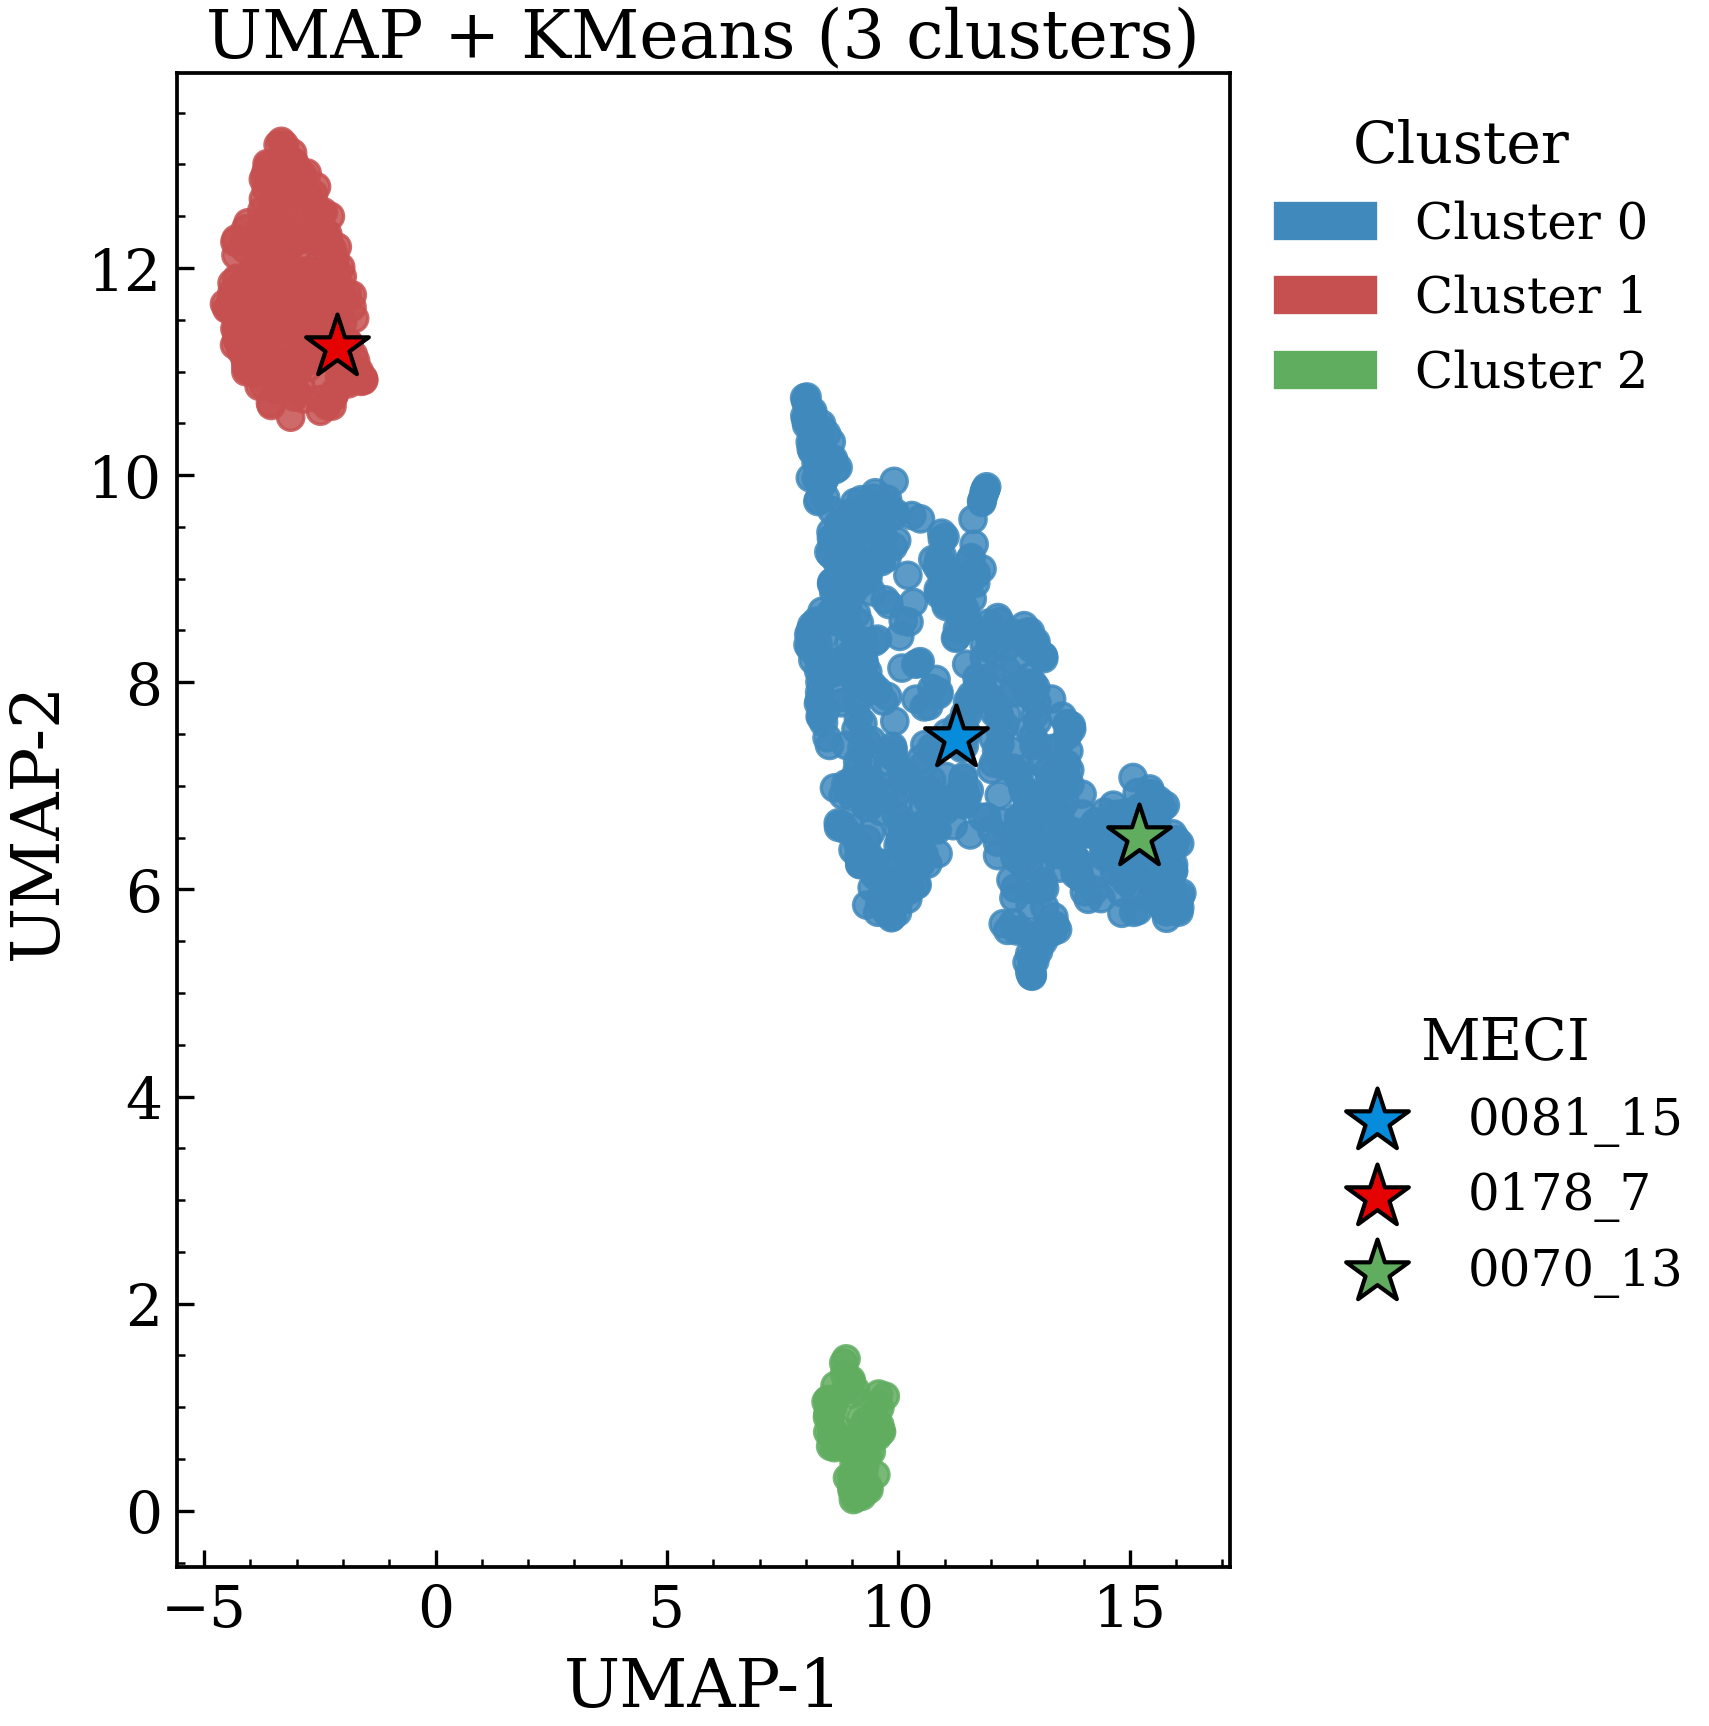

In [51]:
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, init="k-means++", n_init=10, random_state=42)
labels = kmeans.fit_predict(X_umap)

output_rows =[]

for idx_val, cluster_val in zip(idx, labels):
    output_rows.append([idx_val.stem if isinstance(idx_val, Path) else str(idx_val),
                        cluster_val])


import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import numpy as np

# -----------------------------
# Configuration
# -----------------------------
n_star = 3                     # how many last datapoints to highlight
star_size = 250
point_size = 40

# Cluster colors
cluster_colors = [
    "#3f89bd", 
    "#c65050",  
    "#60ad60", 
 
]

# ⭐ Manually chosen star colors (one per starred point, in order)
star_colors = [
    "#068cda",
    "#e40202",
    "#60ad60",  

     
]

cmap = ListedColormap(cluster_colors)

# Indices of starred points (last n)
star_indices = np.arange(len(X_umap) - n_star, len(X_umap))

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(6, 6))

# Normal points
plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=labels,
    cmap=cmap,
    s=point_size,
    alpha=0.85
)

# Starred points (plotted on top)
star_handles = []
for i, star_idx in enumerate(star_indices):
    h = plt.scatter(
        X_umap[star_idx, 0],
        X_umap[star_idx, 1],
        marker="*",
        s=star_size,
        color=star_colors[i],   # ⭐ manual color
        edgecolor="black",
        linewidth=1.0,
        zorder=10,
        label=str(idx[star_idx].stem if hasattr(idx[star_idx], "stem") else idx[star_idx])
    )
    star_handles.append(h)

# -----------------------------
# Labels & formatting
# -----------------------------
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title(f"UMAP + KMeans ({optimal_k} clusters)", fontsize=16)
plt.xlabel("UMAP-1", fontsize=16)
plt.ylabel("UMAP-2", fontsize=16)
plt.grid(False)

# -----------------------------
# Legends
# -----------------------------
# Cluster legend
cluster_patches = [
    mpatches.Patch(color=cluster_colors[i], label=f"Cluster {i}")
    for i in sorted(set(labels))
]

cluster_legend = plt.legend(
    handles=cluster_patches,
    title="Cluster",
    bbox_to_anchor=(1.0, 1),
    loc="upper left",
    title_fontsize=14,
    fontsize=12
)

# Star legend (idx names)
star_legend = plt.legend(
    handles=star_handles,
    title="MECI",
    bbox_to_anchor=(1.05, 0.4),
    loc="upper left",
    title_fontsize=14,
    fontsize=12
)

plt.gca().add_artist(cluster_legend)

plt.tight_layout()
plt.show()


In [27]:
df = pd.DataFrame(output_rows, columns=["idx", "cluster"])
csv_path = "../../../data/clustered/smiles/cartesian/umap/kmeans/benzene/cluster_assignments2.csv"
df.to_csv(csv_path, index=False)

In [ ]:
#### import meci classification, compare adjusted rand membership to labels generated above 